# LeNet 5 with MNIST Keras

***1. IMPORTS***

In [1]:
from tensorflow import keras
from keras.layers import Conv2D,AveragePooling2D,MaxPooling2D,Flatten,Dense
from keras.models import Sequential
from keras.datasets import mnist

***2. Loading the dataset and perform splitting***

In [2]:
(x_train,y_train),(x_test,y_test) = mnist.load_data()

# Peforming reshaping operation

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
# Peforming reshaping operation
print(x_train.shape)
print(x_test.shape)
x_train = x_train.reshape(x_train.shape[0],28,28,1)
x_test = x_test.reshape(x_test.shape[0],28,28,1)
print("\n ------------------Shape after reshaping-----------------------")
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)

 ------------------Shape after reshaping-----------------------
(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [4]:
# Resize 28x28 → 32x32
import tensorflow
x_train = tensorflow.image.resize(x_train, [32, 32])
x_test = tensorflow.image.resize(x_test, [32, 32])

In [5]:
x_train.shape,x_test.shape

(TensorShape([60000, 32, 32, 1]), TensorShape([10000, 32, 32, 1]))

***3. Normalization***

In [6]:
x_train = x_train/255.
x_test = x_test/255.

***4. One Hot Encoding the Labels***

In [7]:
y_train = keras.utils.to_categorical(y_train,10)
y_test = keras.utils.to_categorical(y_test,10)

***5. Network Structure***

In [8]:
# Building the LeNet-5 Model Architecture
model = Sequential()

model.add(Conv2D(filters=6,kernel_size=(5,5),
                 activation='tanh',input_shape=(32,32,1))) #  28 x 28 x 6
model.add(AveragePooling2D(pool_size=(2,2))) # 14 x 14 x 6


model.add(Conv2D(filters=16,kernel_size=(5,5),
                 activation='tanh')) # 10 x 10 x 16
model.add(AveragePooling2D(pool_size=(2,2))) # 5 x 5 x 16


model.add(Conv2D(filters=120,kernel_size=(5,5),
                 activation='tanh')) # 1 x 1 x 120


model.add(Flatten())

model.add(Dense(84,activation='tanh'))
model.add(Dense(10,activation='softmax'))



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 1, 1, 120)      │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

***6. Model Compile***

In [10]:
model.compile(loss=keras.metrics.categorical_crossentropy,optimizer='rmsprop',metrics=['accuracy'])

***7. Model training***

In [11]:
model.fit(x_train,y_train,batch_size=128,epochs=20,verbose=0,validation_data=(x_test, y_test))

***8. Results***

In [12]:
score = model.evaluate(x_test,y_test)
print('Test Loss:', score[0])
print('Test accuracy:', score[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9880 - loss: 0.0475
Test Loss: 0.04745350778102875
Test accuracy: 0.9879999756813049


In [13]:
score = model.evaluate(x_test,y_test)
print('Test Loss:', score[0])
print('Test accuracy:', score[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9880 - loss: 0.0475
Test Loss: 0.04745350778102875
Test accuracy: 0.9879999756813049


# LeNet 5 with MNIST Pytorch

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [15]:
class LeNet(nn.Module):
  def __init__(self):
    super(LeNet,self).__init__()

    self.conv1 = nn.Conv2d(1,6,kernel_size=5)
    self.pool = nn.AvgPool2d(2,2)
    self.conv2 = nn.Conv2d(6,16,kernel_size=5)
    self.conv3 = nn.Conv2d(16,120,kernel_size=5)
    self.fc1 = nn.Linear(120 * 1 * 1,84)
    self.fc2 = nn.Linear(84,10)

  def forward(self,x):
    x = F.tanh(self.conv1(x)) # 28x28x6
    x = self.pool(x)          # 14x14x6
    x = F.tanh(self.conv2(x)) # 10x10x16
    x = self.pool(x)          # 5x5x16
    x = F.tanh(self.conv3(x)) # 1x1x120
    x = x.view(-1,120*1*1)    # 120
    x = F.tanh(self.fc1(x))   # 84
    x = self.fc2(x)           # 10
    return x


model = LeNet()
import torch.optim as optim
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

- `permute()` is used to change the order of dimensions `(axes)` of a tensor.

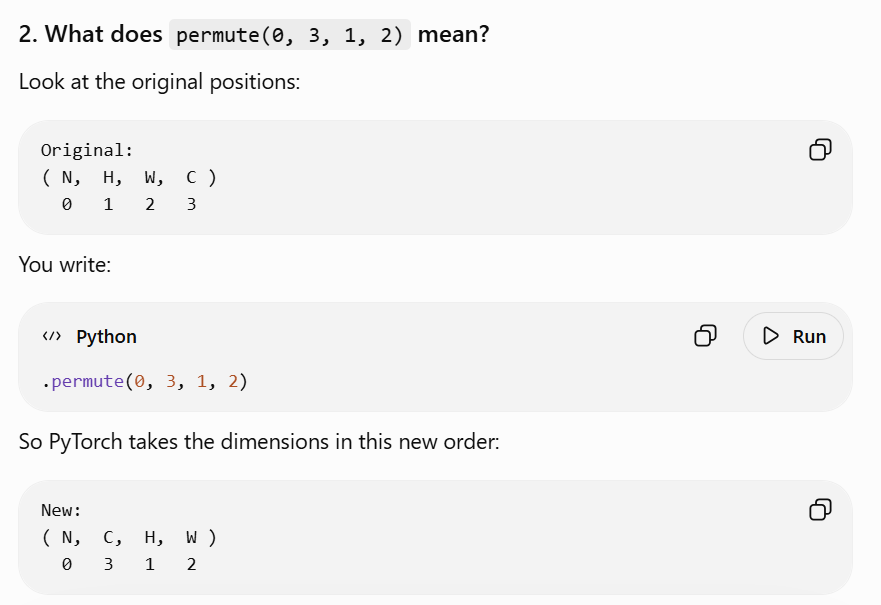

In [18]:
from torch.utils.data import TensorDataset,DataLoader
import torch.nn as nn
import torch.optim as optim

# move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "CPU")
model = model.to(device)
print(device)
print("----------------------------------------------------------\n")

# convert your existing numpy data to PyTorch tensors
x_train_tensor = torch.tensor(x_train.numpy(),dtype=torch.float32).permute(0,3,1,2)
y_train_tensor = torch.tensor(y_train.argmax(axis=1),dtype=torch.long)

x_test_tensor = torch.tensor(x_test.numpy(), dtype=torch.float32).permute(0, 3, 1, 2)
y_test_tensor = torch.tensor(y_test.argmax(axis=1), dtype=torch.long)


# create datasets and loaders
batch_size = 128

train_dataset = TensorDataset(x_train_tensor,y_train_tensor)
train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True)


test_dataset = TensorDataset(x_test_tensor,y_test_tensor)
test_loader = DataLoader(test_dataset,batch_size=batch_size,shuffle=False)

# define loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)


#train model
epochs = 10
for epoch in range(epochs):
  model.train()
  running_loss = 0
  correct = 0
  total = 0

  for img,lbl in train_loader:
    img,lbl = img.to(device),lbl.to(device)

    optimizer.zero_grad()
    outputs = model(img)
    loss = criterion(outputs,lbl)
    loss.backward()
    optimizer.step()

    running_loss += loss.item()
    _,predicted = torch.max(outputs.data,1)
    total += lbl.size(0)  # Added this line
    correct += (predicted == lbl).sum().item() # Added this line

  print("Epoch {}/{} | Loss: {:.4f} | Train Accuracy: {:.2f}%".format(
        epoch + 1, epochs, running_loss / len(train_loader), 100 * correct / total))


# evaluate on test data
model.eval()
correct = 0
total = 0

with torch.no_grad():
  for img,lbl in test_loader:
    img,lbl = img.to(device),lbl.to(device)
    outputs = model(img)
    _,predicted = torch.max(outputs.data,1)
    total += lbl.size(0)
    correct += (predicted == lbl).sum().item()

  print("Test Accuracy: {:.2f}%".format(100 * correct / total))

cuda
----------------------------------------------------------

Epoch 1/10 | Loss: 0.1139 | Train Accuracy: 96.54%
Epoch 2/10 | Loss: 0.0723 | Train Accuracy: 97.78%
Epoch 3/10 | Loss: 0.0537 | Train Accuracy: 98.35%
Epoch 4/10 | Loss: 0.0436 | Train Accuracy: 98.63%
Epoch 5/10 | Loss: 0.0349 | Train Accuracy: 98.91%
Epoch 6/10 | Loss: 0.0287 | Train Accuracy: 99.11%
Epoch 7/10 | Loss: 0.0256 | Train Accuracy: 99.21%
Epoch 8/10 | Loss: 0.0223 | Train Accuracy: 99.32%
Epoch 9/10 | Loss: 0.0178 | Train Accuracy: 99.44%
Epoch 10/10 | Loss: 0.0164 | Train Accuracy: 99.48%
Test Accuracy: 98.50%
